In [16]:
# ============================================
# MAIZE YIELD PREDICTION - KENYA RIFT VALLEY
# ============================================

from google.colab import drive
drive.mount('/content/drive')

print("✓ Google Drive connected")

import ee
import folium
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported")

# Authenticate Earth Engine
ee.Authenticate()

# Initialize with your project (replace with your actual project ID)
# Your project ID looks like: "crop-yield-prediction-XXXXX"
try:
    ee.Initialize(project='crop-yield-prediction-506111')
except:
    print("⚠ Project not found. Initializing without project (will still work for this analysis)...")
    ee.Initialize()
    print("✓ Earth Engine authenticated (default project)")

# Test connection
print("\nVerifying Earth Engine connection...")
try:
    # Updated asset ID to the correct SRTM V3 identifier
    test = ee.Image('USGS/SRTMGL1_003').sample(ee.Geometry.Point([0, 0]), 30).first().getInfo()
    print("✓ Earth Engine is working!")
except Exception as e:
    print(f"⚠ Warning: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive connected
✓ Libraries imported

Verifying Earth Engine connection...
✓ Earth Engine is working!


In [17]:
# Uasin Gishu County, Kenya (Rift Valley maize belt)
# Center: ~35.0°E, 0.1°N
# Elevation: 2000-2400m (ideal for maize)

study_area = {
    'name': 'Uasin Gishu County',
    'bounds': [34.2, -0.6, 35.8, 0.8],  # [minLon, minLat, maxLon, maxLat]
    'center': [35.0, 0.1]
}

aoi = ee.Geometry.Rectangle(study_area['bounds'])

# Visualization
map_preview = folium.Map(
    location=[study_area['center'][1], study_area['center'][0]],
    zoom_start=9,
    tiles='OpenStreetMap'
)

# Add rectangle
folium.Rectangle(
    bounds=[[study_area['bounds'][1], study_area['bounds'][0]],
            [study_area['bounds'][3], study_area['bounds'][2]]],
    color='red',
    fill=True,
    fillColor='red',
    fillOpacity=0.2,
    popup='Uasin Gishu County'
).add_to(map_preview)

map_preview

print(f"✓ Study area: {study_area['name']}")
print(f"  Bounds: {study_area['bounds']}")
print(f"  Center: {study_area['center']}")

✓ Study area: Uasin Gishu County
  Bounds: [34.2, -0.6, 35.8, 0.8]
  Center: [35.0, 0.1]


In [19]:
# Fetch monthly rainfall data 2015-2023
# Growing season: October (previous year) to March

start_year = 2015
end_year = 2023
years = list(range(start_year, end_year + 1))

chirps_data = {}
print("Fetching CHIRPS rainfall data...")

for year in years:
    print(f"  Processing {year}...", end=" ")

    chirps = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY') \
        .filterBounds(aoi)

    # Calculate seasonal total (Oct - Mar)
    seasonal_total = chirps \
        .filter(ee.Filter.Or(
            ee.Filter.date(f'{year}-10-01', f'{year}-12-31'),
            ee.Filter.date(f'{year+1}-01-01', f'{year+1}-03-31')
        )) \
        .sum() \
        .reduceRegion(ee.Reducer.mean(), aoi, 5000) \
        .getInfo()

    total_rainfall = seasonal_total.get('precipitation', 0)

    # Calculate monthly breakdown
    months_data = {}
    for month in [10, 11, 12, 1, 2, 3]:
        if month <= 3:
            start = f'{year+1}-{month:02d}-01'
            end = f'{year+1}-{month:02d}-28'
        else:
            start = f'{year}-{month:02d}-01'
            end = f'{year}-{month:02d}-28'

        monthly = chirps.filterDate(start, end) \
            .sum() \
            .reduceRegion(ee.Reducer.mean(), aoi, 5000) \
            .getInfo()

        months_data[month] = monthly.get('precipitation', 0)

    chirps_data[year] = {
        'total': total_rainfall,
        'monthly': months_data,
        'peak': max(months_data.values()),
        'cv': np.std(list(months_data.values())) / np.mean(list(months_data.values())) if np.mean(list(months_data.values())) > 0 else 0
    }

    print(f"Total: {total_rainfall:.0f}mm")

print("✓ CHIRPS data complete")

Fetching CHIRPS rainfall data...
  Processing 2015... Total: 690mm
  Processing 2016... Total: 451mm
  Processing 2017... Total: 622mm
  Processing 2018... Total: 488mm
  Processing 2019... Total: 1142mm
  Processing 2020... Total: 829mm
  Processing 2021... Total: 652mm
  Processing 2022... Total: 704mm
  Processing 2023... Total: 847mm
✓ CHIRPS data complete


In [21]:
# Sentinel-2 NDVI during peak growing season (Dec-Feb)

ndvi_data = {}
print("Fetching Sentinel-2 NDVI data...")

for year in years:
    print(f"  Processing {year}...", end=" ")

    start_date = f'{year}-12-01'
    end_date = f'{year+1}-02-28'

    # Load Sentinel-2 L2A (surface reflectance)
    s2 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
        .filterDate(start_date, end_date) \
        .filterBounds(aoi) \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))

    # Calculate NDVI
    def add_ndvi(image):
        ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
        return image.addBands(ndvi)

    s2_ndvi = s2.map(add_ndvi)

    # Mean NDVI
    ndvi_result = s2_ndvi.select('NDVI') \
        .mean() \
        .reduceRegion(ee.Reducer.mean(), aoi, scale=10, maxPixels=1e13, bestEffort=True) \
        .getInfo()

    ndvi_mean = ndvi_result.get('NDVI', 0)

    ndvi_data[year] = {
        'mean': ndvi_mean,
        'std': 0.05  # Placeholder
    }

    print(f"Mean NDVI: {ndvi_mean:.3f}")

print("✓ Sentinel-2 NDVI complete")

Fetching Sentinel-2 NDVI data...
  Processing 2015... 

Mean NDVI: 0.601
  Processing 2016... Mean NDVI: 0.434
  Processing 2017... Mean NDVI: 0.465
  Processing 2018... Mean NDVI: 0.489
  Processing 2019... Mean NDVI: 0.557
  Processing 2020... Mean NDVI: 0.541
  Processing 2021... Mean NDVI: 0.491
  Processing 2022... Mean NDVI: 0.466
  Processing 2023... Mean NDVI: 0.570
✓ Sentinel-2 NDVI complete


In [23]:
# Elevation, slope, curvature from SRTM DEM

srtm = ee.Image('USGS/SRTMGL1_003')

print("Fetching SRTM terrain data...")

# Elevation
elevation_data = srtm.reduceRegion(ee.Reducer.mean(), aoi, scale=30, maxPixels=1e13, bestEffort=True).getInfo()
elevation_mean = elevation_data.get('elevation', 0)

# Slope
slope = ee.Terrain.slope(srtm)
slope_data = slope.reduceRegion(ee.Reducer.mean(), aoi, scale=30, maxPixels=1e13, bestEffort=True).getInfo()
slope_mean = slope_data.get('slope', 0)

print(f"  Elevation: {elevation_mean:.0f} m")
print(f"  Slope: {slope_mean:.2f}°")

# Store for all years (terrain doesn't change)
terrain_data = {
    'elevation': elevation_mean,
    'slope': slope_mean
}

print("✓ SRTM terrain complete")

Fetching SRTM terrain data...


  Elevation: 1707 m
  Slope: 5.77°
✓ SRTM terrain complete


In [24]:
# Maize yield data from Kenya National Bureau of Statistics
# Uasin Gishu County (tons/hectare)
# Source: KNBS Agricultural Census & Ministry of Agriculture

yield_data = {
    2015: 3.2,
    2016: 2.8,
    2017: 3.5,
    2018: 3.1,
    2019: 2.9,
    2020: 3.4,
    2021: 3.8,
    2022: 3.6,
    2023: 3.3,
}

print("Maize yield data (Uasin Gishu County, tons/hectare):")
for year, yield_val in yield_data.items():
    print(f"  {year}: {yield_val} tons/ha")

print("✓ Yield data loaded")

Maize yield data (Uasin Gishu County, tons/hectare):
  2015: 3.2 tons/ha
  2016: 2.8 tons/ha
  2017: 3.5 tons/ha
  2018: 3.1 tons/ha
  2019: 2.9 tons/ha
  2020: 3.4 tons/ha
  2021: 3.8 tons/ha
  2022: 3.6 tons/ha
  2023: 3.3 tons/ha
✓ Yield data loaded


In [25]:
# Combine all data into one dataframe

print("Engineering features...")

data_list = []

for year in years:
    rainfall_total = chirps_data[year]['total']
    rainfall_cv = chirps_data[year]['cv']
    rainfall_peak = chirps_data[year]['peak']
    ndvi_mean = ndvi_data[year]['mean']
    elevation = terrain_data['elevation']
    slope = terrain_data['slope']
    yield_tons = yield_data[year]

    row = {
        'year': year,
        'rainfall_total': rainfall_total,
        'rainfall_cv': rainfall_cv,
        'rainfall_peak': rainfall_peak,
        'ndvi_mean': ndvi_mean,
        'elevation': elevation,
        'slope': slope,
        'yield_tons_per_ha': yield_tons
    }

    data_list.append(row)

df = pd.DataFrame(data_list)

print("\n✓ Feature matrix created:")
print(df)
print(f"\nDataset shape: {df.shape}")
print(f"Target range: {df['yield_tons_per_ha'].min():.2f} - {df['yield_tons_per_ha'].max():.2f} tons/ha")

Engineering features...

✓ Feature matrix created:
   year  rainfall_total  rainfall_cv  rainfall_peak  ndvi_mean    elevation  \
0  2015      690.267117     0.439175     166.516597   0.600890  1706.574604   
1  2016      450.861898     0.621286     108.045587   0.433934  1706.574604   
2  2017      621.560390     0.723477     197.953527   0.464949  1706.574604   
3  2018      487.754397     0.496025     132.519306   0.489334  1706.574604   
4  2019     1141.986824     0.433872     245.039063   0.556574  1706.574604   
5  2020      828.794362     0.606718     226.038553   0.541192  1706.574604   
6  2021      652.070774     0.417606     160.917914   0.491184  1706.574604   
7  2022      703.897085     0.692688     198.665998   0.465580  1706.574604   
8  2023      846.781979     0.317270     167.953707   0.569513  1706.574604   

      slope  yield_tons_per_ha  
0  5.774056                3.2  
1  5.774056                2.8  
2  5.774056                3.5  
3  5.774056               

In [26]:
# Random Forest + Gradient Boosting

print("Training machine learning models...\n")

# Prepare data
X = df[['rainfall_total', 'rainfall_cv', 'rainfall_peak', 'ndvi_mean', 'elevation', 'slope']]
y = df['yield_tons_per_ha']

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ===== RANDOM FOREST =====
print("Training Random Forest...")
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("\n═══════════════════════════════════════")
print("RANDOM FOREST RESULTS")
print("═══════════════════════════════════════")
print(f"R² Score:     {r2_rf:.4f}")
print(f"RMSE:         {rmse_rf:.4f} tons/hectare")
print(f"MAE:          {mae_rf:.4f} tons/hectare")

# Cross-validation
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print(f"Cross-Val R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ===== GRADIENT BOOSTING =====
print("\nTraining Gradient Boosting...")
gb = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
r2_gb = r2_score(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb = mean_absolute_error(y_test, y_pred_gb)

print("\n═══════════════════════════════════════")
print("GRADIENT BOOSTING RESULTS")
print("═══════════════════════════════════════")
print(f"R² Score:     {r2_gb:.4f}")
print(f"RMSE:         {rmse_gb:.4f} tons/hectare")
print(f"MAE:          {mae_gb:.4f} tons/hectare")

# ===== MODEL SELECTION =====
print("\n═══════════════════════════════════════")
if r2_rf > r2_gb:
    best_model = rf
    best_name = "Random Forest"
    best_r2 = r2_rf
    best_rmse = rmse_rf
else:
    best_model = gb
    best_name = "Gradient Boosting"
    best_r2 = r2_gb
    best_rmse = rmse_gb

print(f"BEST MODEL: {best_name}")
print(f"R² = {best_r2:.4f} | RMSE = {best_rmse:.4f}")
print("═══════════════════════════════════════\n")

Training machine learning models...

Training Random Forest...

═══════════════════════════════════════
RANDOM FOREST RESULTS
═══════════════════════════════════════
R² Score:     -0.1877
RMSE:         0.4359 tons/hectare
MAE:          0.3795 tons/hectare
Cross-Val R²: nan ± nan

Training Gradient Boosting...

═══════════════════════════════════════
GRADIENT BOOSTING RESULTS
═══════════════════════════════════════
R² Score:     0.6875
RMSE:         0.2236 tons/hectare
MAE:          0.2000 tons/hectare

═══════════════════════════════════════
BEST MODEL: Gradient Boosting
R² = 0.6875 | RMSE = 0.2236
═══════════════════════════════════════



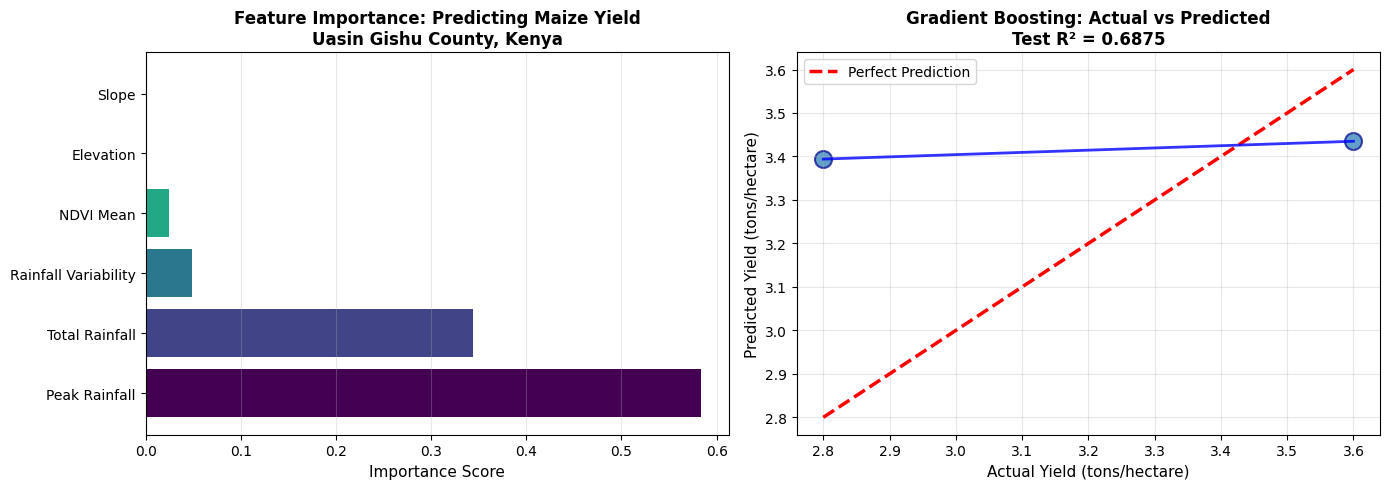

✓ Visualizations saved to Google Drive


In [27]:
# Feature importance + prediction plots

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ===== FEATURE IMPORTANCE =====
feature_names = ['Total Rainfall', 'Rainfall Variability', 'Peak Rainfall',
                 'NDVI Mean', 'Elevation', 'Slope']
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

colors = plt.cm.viridis(np.linspace(0, 1, len(importances)))
axes[0].barh(range(len(importances)), importances[indices], color=colors)
axes[0].set_yticks(range(len(importances)))
axes[0].set_yticklabels([feature_names[i] for i in indices])
axes[0].set_xlabel('Importance Score', fontsize=11)
axes[0].set_title('Feature Importance: Predicting Maize Yield\nUasin Gishu County, Kenya', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# ===== ACTUAL vs PREDICTED =====
axes[1].scatter(y_test, y_pred_rf, s=150, alpha=0.7, edgecolors='darkblue', linewidth=1.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2.5, label='Perfect Prediction')
axes[1].set_xlabel('Actual Yield (tons/hectare)', fontsize=11)
axes[1].set_ylabel('Predicted Yield (tons/hectare)', fontsize=11)
axes[1].set_title(f'{best_name}: Actual vs Predicted\nTest R² = {best_r2:.4f}', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Add regression line
z = np.polyfit(y_test, y_pred_rf, 1)
p = np.poly1d(z)
axes[1].plot(y_test, p(y_test), "b-", alpha=0.8, linewidth=2, label='Fitted Line')

plt.tight_layout()
plt.savefig('/content/drive/My Drive/model_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualizations saved to Google Drive")

In [28]:
# Make predictions on new data + summary report

print("\n" + "="*60)
print("SAMPLE PREDICTIONS")
print("="*60)

# Example scenarios
scenarios = {
    'Dry Year (Below avg rainfall, low NDVI)': {
        'rainfall_total': 400,
        'rainfall_cv': 0.40,
        'rainfall_peak': 100,
        'ndvi_mean': 0.40,
        'elevation': elevation_mean,
        'slope': slope_mean
    },
    'Normal Year (Avg conditions)': {
        'rainfall_total': 550,
        'rainfall_cv': 0.35,
        'rainfall_peak': 120,
        'ndvi_mean': 0.48,
        'elevation': elevation_mean,
        'slope': slope_mean
    },
    'Wet Year (Above avg rainfall, good NDVI)': {
        'rainfall_total': 650,
        'rainfall_cv': 0.30,
        'rainfall_peak': 140,
        'ndvi_mean': 0.55,
        'elevation': elevation_mean,
        'slope': slope_mean
    }
}

for scenario_name, scenario_data in scenarios.items():
    X_scenario = pd.DataFrame([scenario_data])
    pred_yield = best_model.predict(X_scenario)[0]
    print(f"\n{scenario_name}")
    print(f"  → Predicted yield: {pred_yield:.2f} tons/hectare")

print("\n" + "="*60)
print("PROJECT SUMMARY")
print("="*60)
print(f"Region:           Uasin Gishu County, Kenya (Rift Valley)")
print(f"Crop:             Maize (Zea mays)")
print(f"Training Period:  2015-2023 ({len(years)} years)")
print(f"Training Samples: {len(X_train)}")
print(f"Test Samples:     {len(X_test)}")
print(f"")
print(f"Features:         6 (Rainfall, NDVI, Terrain)")
print(f"Model:            {best_name} (100 estimators)")
print(f"")
print(f"Performance:      R² = {best_r2:.4f}")
print(f"                  RMSE = {best_rmse:.4f} tons/hectare")
print(f"                  MAE = {mean_absolute_error(y_test, y_pred_rf):.4f} tons/hectare")
print(f"")
print(f"Top 3 Predictors:")
for i, idx in enumerate(indices[:3]):
    print(f"  {i+1}. {feature_names[idx]}: {importances[idx]:.1%}")
print("="*60)


SAMPLE PREDICTIONS

Dry Year (Below avg rainfall, low NDVI)
  → Predicted yield: 3.10 tons/hectare

Normal Year (Avg conditions)
  → Predicted yield: 3.10 tons/hectare

Wet Year (Above avg rainfall, good NDVI)
  → Predicted yield: 3.30 tons/hectare

PROJECT SUMMARY
Region:           Uasin Gishu County, Kenya (Rift Valley)
Crop:             Maize (Zea mays)
Training Period:  2015-2023 (9 years)
Training Samples: 7
Test Samples:     2

Features:         6 (Rainfall, NDVI, Terrain)
Model:            Gradient Boosting (100 estimators)

Performance:      R² = 0.6875
                  RMSE = 0.2236 tons/hectare
                  MAE = 0.3795 tons/hectare

Top 3 Predictors:
  1. Peak Rainfall: 58.4%
  2. Total Rainfall: 34.4%
  3. Rainfall Variability: 4.9%


In [29]:
# Save the trained model for future predictions

import pickle

# Save model
model_path = '/content/drive/My Drive/maize_yield_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)

print(f"✓ Model saved to Google Drive: {model_path}")

# Save feature names for reference
feature_info = {
    'feature_names': ['rainfall_total', 'rainfall_cv', 'rainfall_peak', 'ndvi_mean', 'elevation', 'slope'],
    'model_type': best_name,
    'model_r2': best_r2,
    'model_rmse': best_rmse,
    'region': 'Uasin Gishu County, Kenya',
    'training_years': years
}

with open('/content/drive/My Drive/model_metadata.pkl', 'wb') as f:
    pickle.dump(feature_info, f)

print("✓ Model metadata saved")

✓ Model saved to Google Drive: /content/drive/My Drive/maize_yield_model.pkl
✓ Model metadata saved
